In [40]:
import os
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [41]:
import matplotlib.font_manager as fm

fonts = sorted(set([f.name for f in fm.fontManager.ttflist]))
for f in fonts:
    print(f)

.Aqua Kana
.Keyboard
.New York
.SF Arabic
.SF Arabic Rounded
.SF Compact
.SF Compact Rounded
.SF NS Mono
.SF NS Rounded
.ThonburiUI
Academy Engraved LET
Adelle Sans Devanagari
AkayaKanadaka
AkayaTelivigala
Al Bayan
Al Nile
Al Tarikh
American Typewriter
Andale Mono
Annai MN
Apple Braille
Apple Chancery
Apple LiGothic
Apple LiSung
Apple SD Gothic Neo
Apple Symbols
AppleGothic
AppleMyungjo
Arial
Arial Black
Arial Hebrew
Arial Narrow
Arial Rounded MT Bold
Arial Unicode MS
Arima Koshi
Arima Madurai
Athelas
Avenir
Avenir Next
Avenir Next Condensed
Ayuthaya
BM Dohyeon
BM Hanna 11yrs Old
BM Hanna Air
BM Hanna Pro
BM Jua
BM Kirang Haerang
BM Yeonsung
Baghdad
Bai Jamjuree
Baloo 2
Baloo Bhai 2
Baloo Bhaijaan
Baloo Bhaina 2
Baloo Chettan 2
Baloo Da 2
Baloo Paaji 2
Baloo Tamma 2
Baloo Tammudu 2
Baloo Thambi 2
Bangla MN
Bangla Sangam MN
Baoli SC
Baskerville
Beirut
BiauKaiHK
Big Caslon
Bodoni 72
Bodoni 72 Oldstyle
Bodoni 72 Smallcaps
Bodoni Ornaments
Bradley Hand
Brush Script MT
Cambay Devanagari
Cha

In [42]:
import matplotlib as mpl

import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Optima'
sns.set_theme(style="whitegrid", font="Optima")

import matplotlib.pyplot as plt

plt.rcParams.update({
    'font.family': 'Helvetica',
    'font.size': 11,
    'axes.titlesize': 15,
    'axes.titleweight': 'bold',
    'axes.labelsize': 13,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
})

In [43]:
df_cancelled = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Cancelled operations.csv", sep=';')
df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_63913/3600004165.py:2: DtypeWarning: Columns (13,14,21,22,23,24,25,29) have mixed types. Specify dtype option on import or set low_memory=False.
  df_complete = pd.read_csv("../Data and descriptions/Case Rigshospitalet - Completed operations.csv", sep = ';')


In [44]:
# remove columns with staff and resources
df_complete_wo = df_complete.drop(columns=[col for col in df_complete.columns if col.startswith("Ressource")])
df_complete_wo = df_complete_wo.drop(columns=[col for col in df_complete_wo.columns if col.startswith("Staff")])
df_complete_wo.describe()

,Case-ID Anonymous,Patient Alder,Operationsgang ID,Forsinkelse (minutter),Overskredet (minutter)
count,133158.000000,133158.000000,133158.000000,132491.000000,132537.000000
mean,60156.037437,53.788244,40663.550909,20.511642,25.346198
std,34927.061620,24.889920,52262.972747,50.977296,68.894706
min,1.000000,0.000000,618.000000,-3045.000000,-3003.000000
25%,29928.250000,34.000000,622.000000,0.000000,-10.000000
50%,60097.500000,61.000000,625.000000,14.000000,23.000000
75%,90338.750000,74.000000,107621.000000,40.000000,57.000000
max,120868.000000,107.000000,133218.000000,1585.000000,1560.000000


In [45]:
# Make datetime objects
df_complete_wo['Dato'] = pd.to_datetime(df_complete_wo['Dato'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Pt ankommet til hospitalet'] = pd.to_datetime(df_complete_wo['Pt ankommet til hospitalet'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Planlagt stue klargøring start'] = pd.to_datetime(df_complete_wo['Planlagt stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargøring start'] = pd.to_datetime(df_complete_wo['Stue klargøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue klargjort'] = pd.to_datetime(df_complete_wo['Stue klargjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen'] = pd.to_datetime(df_complete_wo['Patient på stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient på stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient på stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistart'] = pd.to_datetime(df_complete_wo['Anæstesistart'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesi melder klar'] = pd.to_datetime(df_complete_wo['Anæstesi melder klar'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure start'] = pd.to_datetime(df_complete_wo['Procedure start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Procedure slut'] = pd.to_datetime(df_complete_wo['Procedure slut'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient klar til afgang'] = pd.to_datetime(df_complete_wo['Patient klar til afgang'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen (Planlagt)'] = pd.to_datetime(df_complete_wo['Patient forlader stuen (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader stuen'] = pd.to_datetime(df_complete_wo['Patient forlader stuen'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort (Planlagt)'] = pd.to_datetime(df_complete_wo['Stue rengjort (Planlagt)'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengøring start'] = pd.to_datetime(df_complete_wo['Stue rengøring start'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Stue rengjort'] = pd.to_datetime(df_complete_wo['Stue rengjort'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['I opvågning'] = pd.to_datetime(df_complete_wo['I opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Anæstesistop'] = pd.to_datetime(df_complete_wo['Anæstesistop'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Klar til udskrivelse efter opvågning'] = pd.to_datetime(df_complete_wo['Klar til udskrivelse efter opvågning'], format='%Y-%m-%d %H:%M:%S,%f')
df_complete_wo['Patient forlader afdeling'] = pd.to_datetime(df_complete_wo['Patient forlader afdeling'], format='%Y-%m-%d %H:%M:%S,%f')

In [46]:
df_complete_wo["Speciale"].nunique()

32

In [47]:
#kun speciale med over 1000 observationer
# Find specialer med over 1000 observationer
store_specialer = df_complete_wo['Speciale'].value_counts()
store_specialer = store_specialer[store_specialer > 2000].index
# Filtrer dataframe
df_filtered = df_complete_wo[df_complete_wo['Speciale'].isin(store_specialer)]

print(df_filtered['Speciale'].unique())

['Øre-næse-hals' 'Plastikkirurgi' 'Tand- mund- og kæbekirurgi'
 'Øjenkirurgi' 'Børnekirurgi' 'Karkirurgi' 'Thoraxkirurgi' 'Hjertekirurgi'
 'Urologi' 'Kirurgi' 'Neurokirurgi' 'Gynækologi' 'Gynækologi-obstetrik'
 'Rygkirurgi']


In [48]:
print(df_filtered['Speciale'].nunique())

14


## Development in Specialities

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_63913/2299023996.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered["År"] = df_filtered['Dato'].dt.year


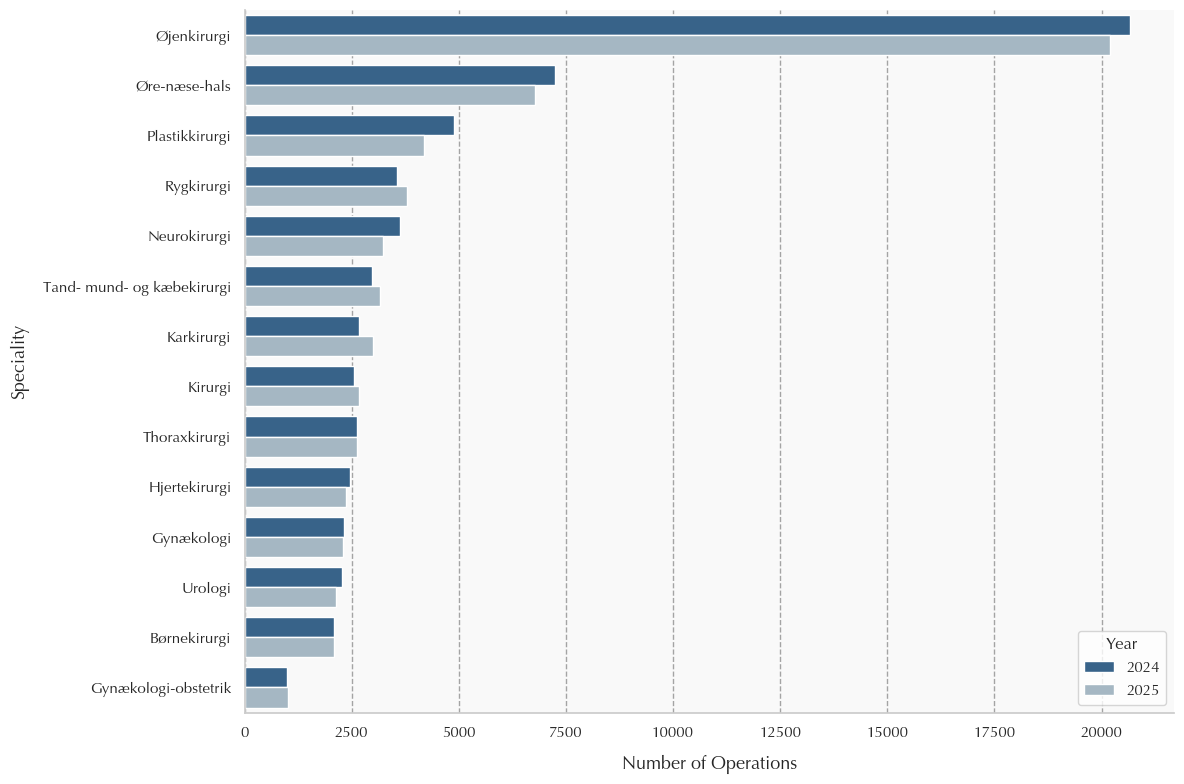

In [49]:

df_filtered["År"] = df_filtered['Dato'].dt.year

# Vi tager de 15 største specialer for at holde det overskueligt
plot_data = df_filtered.groupby(['År', 'Speciale']).size().reset_index(name='Antal')
top_specialer = df_filtered['Speciale'].value_counts().nlargest(15).index
filtered_data = plot_data[plot_data['Speciale'].isin(top_specialer)]

# Sorter efter antals
filtered_data = filtered_data.sort_values('Antal', ascending=False)

fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(data=filtered_data, x='Antal', y='Speciale', hue='År', 
            palette=['#2a6496', '#a0b8c8'], ax=ax)

#ax.set_title('Development in Specialities (Top 15): 2024 vs 2025', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Number of Operations', fontsize=13, labelpad=10)
ax.set_ylabel('Speciality', fontsize=13, labelpad=10)

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_facecolor('#f9f9f9')
ax.xaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

ax.legend(title='Year', fontsize=11, title_fontsize=12)
# Sæt font på BEGGE

plt.tight_layout()
plt.show()

## Distribution of Delays per Speciality

/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_63913/3041091071.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_63913/3041091071.py:8: UserWarning: 
The palette list has fewer values (1) than needed (14) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(


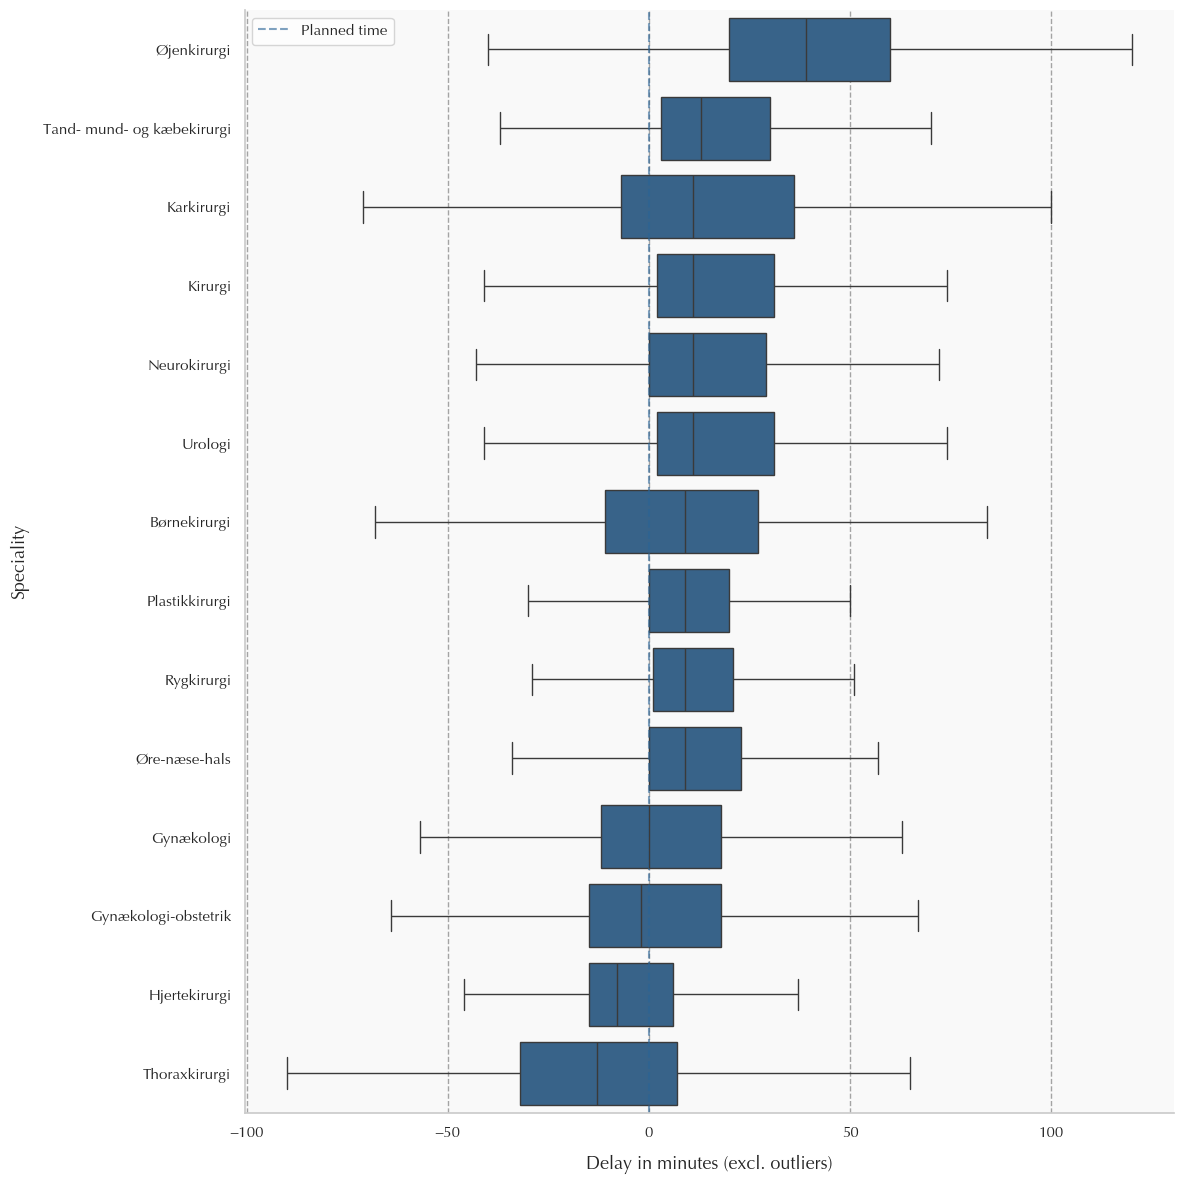

In [50]:
# 1. Beregn rækkefølgen baseret på median
order = df_filtered.groupby('Speciale')['Forsinkelse (minutter)'].median().sort_values(ascending=False).index

# 2. Opsæt figuren
fig, ax = plt.subplots(figsize=(12, 12))

# 3. Lav boxplottet
sns.boxplot(
    data=df_complete_wo, 
    x="Forsinkelse (minutter)", 
    y='Speciale', 
    order=order, 
    palette=['#2a6496'],
    ax=ax, 
    showfliers=False
)

# 4. Styling
#ax.set_title('Distribution of Delays per Speciality', fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Delay in minutes (excl. outliers)', fontsize=13, labelpad=10)
ax.set_ylabel('Speciality', fontsize=13, labelpad=10)

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

ax.set_facecolor('#f9f9f9')
ax.xaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

ax.axvline(0, color='#2a6496', linestyle='--', alpha=0.6, label='Planned time')
ax.legend(fontsize=11)

plt.tight_layout()
plt.show()

## Forsinkelse (minutter) - Middelværdi og STD per Operationsgang ID"

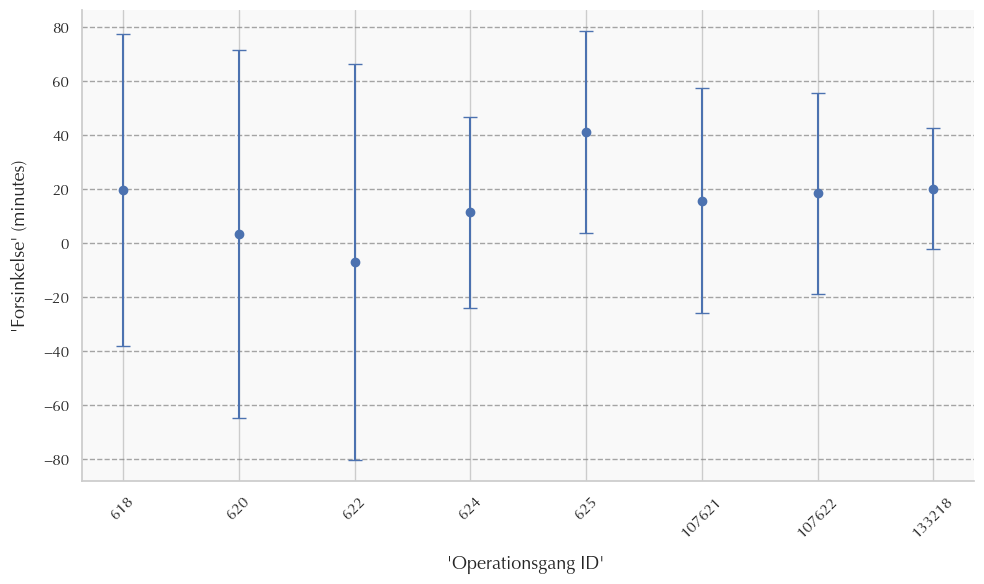

In [51]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

dfs = {k: v for k, v in df_complete.groupby('Operationsgang ID')}
column = 'Forsinkelse (minutter)'

keys = []
means = []
stds = []

for k, d in dfs.items():
    keys.append(k)
    means.append(d[column].mean())
    stds.append(d[column].std())

keys_str = [str(k) for k in keys]
ax.errorbar(keys_str, means, yerr=stds, fmt='o', capsize=5)  # Brug ax. i stedet for plt.

# Pænere stil
ax.set_xlabel("'Operationsgang ID' ", fontsize=13, labelpad=10)
ax.set_ylabel("'Forsinkelse' (minutes)", fontsize=13, labelpad=10)
#ax.set_title("Forsinkelse (minutter) - Middelværdi og STD per Operationsgang ID", fontsize=15, fontweight='bold', pad=15)

# Roter x-labels så de ikke overlapper
ax.tick_params(axis='x', rotation=45, labelsize=11)
ax.tick_params(axis='y', labelsize=11)

# Fjern ramme på toppen og højre side
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Lys baggrund / grid
ax.set_facecolor('#f9f9f9')
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

## Operationsgangs comparison

In [52]:
# Hvor forskinket er den resterende øjnkirugi
group1 =  df_complete_wo[df_complete_wo['Operationsgang ID'] == 625]
group2 =  df_complete_wo[df_complete_wo['Operationsgang ID'] != 625]
group1 =  group1[group1['Speciale'] == 'Øjenkirurgi']["Forsinkelse (minutter)"]
group2 =  group2[group2['Speciale'] == 'Øjenkirurgi']["Forsinkelse (minutter)"]


/var/folders/t7/k_81cy8x6zg28rjf0wl09fl00000gn/T/ipykernel_63913/4219267871.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([group1, group2], labels=['ID = 625', 'ID ≠ 625'],


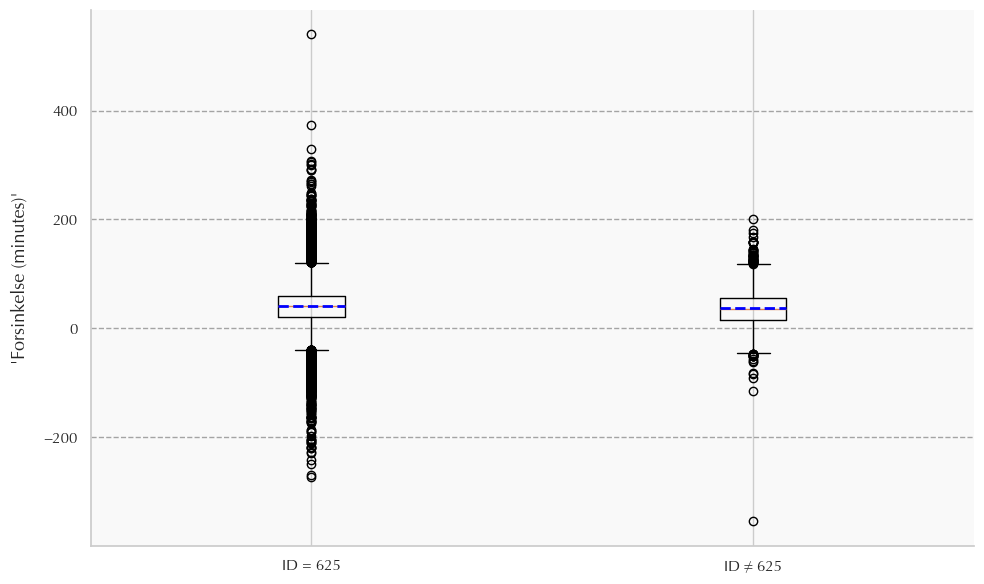

ID = 625 Mean: 41.26849816849817
ID = 625 Std Dev: 37.271304326012604
ID ≠ 625 Mean: 37.744542320949826
ID ≠ 625 Std Dev: 33.696928528175654


In [53]:
fig, ax = plt.subplots(figsize=(10, 6))

group1 = pd.to_numeric(group1, errors='coerce').dropna()
group2 = pd.to_numeric(group2, errors='coerce').dropna()

meanprops = dict(color='blue', linewidth=2)

ax.boxplot([group1, group2], labels=['ID = 625', 'ID ≠ 625'],
           showmeans=True, meanline=True, meanprops=meanprops)

ax.set_ylabel("'Forsinkelse (minutes)'", fontsize=13, labelpad=10)
#ax.set_title("Forsinkelse (minutter) - Sammenligning af Operationsgang ID", fontsize=15, fontweight='bold', pad=15)

ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=11)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

#make facecolor blue 

ax.set_facecolor('#f9f9f9') 
ax.yaxis.grid(True, linestyle='--', alpha=0.7, color='gray')
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

print("ID = 625 Mean:", group1.mean())
print("ID = 625 Std Dev:", group1.std())
print("ID ≠ 625 Mean:", group2.mean())
print("ID ≠ 625 Std Dev:", group2.std())

## Cancellation pie plot

In [54]:
aflyst_efter_planlægning =  df_cancelled[df_cancelled['Aflyst efter operationsprogrammet er afsluttet?'] == 'Ja']
aflyst_før_planlægning =  df_cancelled[df_cancelled['Aflyst efter operationsprogrammet er afsluttet?'] == 'Nej']

scenarie1 = aflyst_efter_planlægning[aflyst_efter_planlægning['Aflyst på dagen for operationen? '] == 'Ja']
scenarie2 = aflyst_før_planlægning[aflyst_før_planlægning['Aflyst på dagen for operationen? '] == 'Nej']
scenarie3 = aflyst_efter_planlægning[aflyst_efter_planlægning['Aflyst på dagen for operationen? '] == 'Nej']

scenarie1: 66
scenarie2: 495
scenarie3: 14


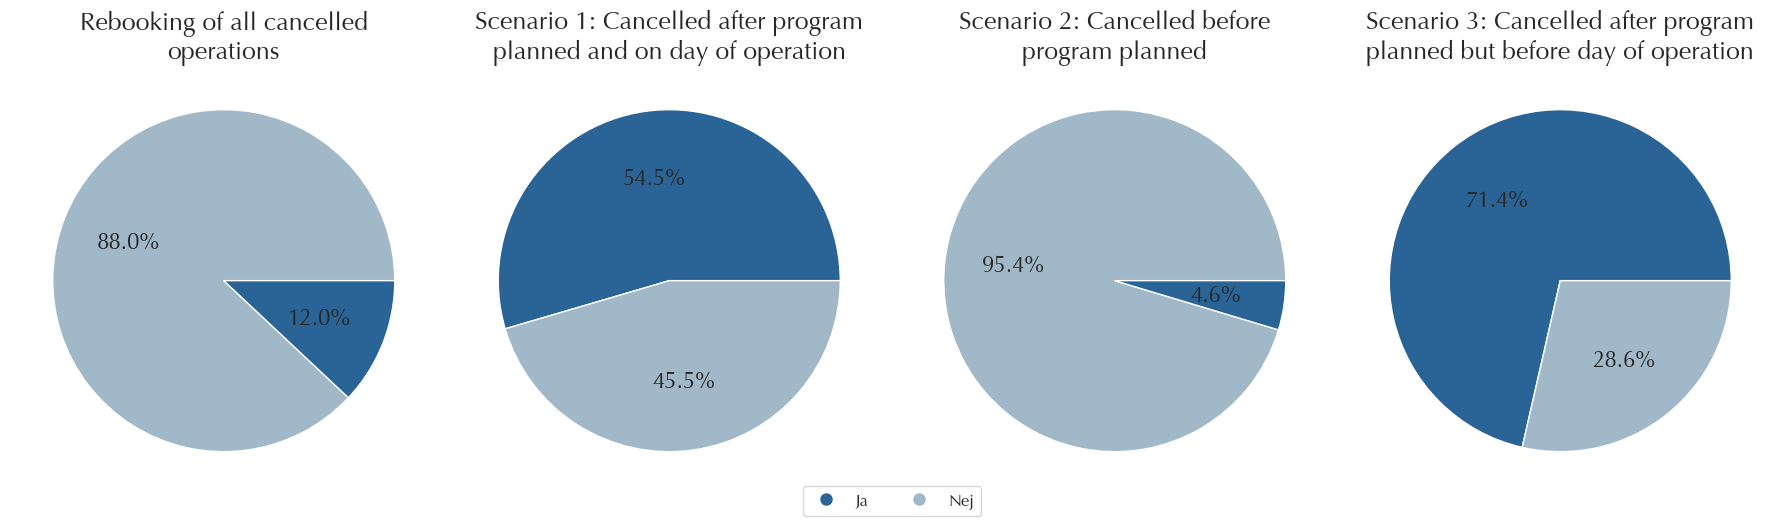

In [55]:
import matplotlib.pyplot as plt
import textwrap

# Counts
ombookning_counts = df_cancelled['Ombooket'].value_counts()
scenarie1_count = scenarie1['Ombooket'].value_counts()
scenarie2_count = scenarie2['Ombooket'].value_counts()
scenarie3_count = scenarie3['Ombooket'].value_counts()

print("scenarie1:", len(scenarie1) )
print("scenarie2:", len(scenarie2) )
print("scenarie3:", len(scenarie3) )



datasets = [
    ("Rebooking of all cancelled operations", ombookning_counts),
    ("Scenario 1: Cancelled after program planned and on day of operation", scenarie1_count),
    ("Scenario 2: Cancelled before program planned", scenarie2_count),
    ("Scenario 3: Cancelled after program planned but before day of operation", scenarie3_count),
]

# Colors
color_map = {
    "Ja": "#2a6496",
    "Nej": "#a0b8c8"
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes = axes.flatten()

for ax, (title, data) in zip(axes, datasets):
    labels = data.index
    colors = [color_map[label] for label in labels]

    ax.pie(
        data,
        labels=None,
        autopct='%1.1f%%',
        colors=colors,
        textprops={'fontsize': 16}  # slightly bigger % text
    )

    # Wrap titles and increase size
    wrapped_title = "\n".join(textwrap.wrap(title, 35))
    ax.set_title(wrapped_title, fontsize=18)

# Shared legend (bigger text)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=key,
               markerfacecolor=color_map[key], markersize=10)
    for key in color_map
]

fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=12)

plt.tight_layout()
plt.show()

In [56]:
#Pørver bare lige for første cancelled operation - så dvs dato: 2024-01-03 og stue: CKO LEJE 01
from Helpers import get_dataframe_by_val_in_key
df_complete_stue = get_dataframe_by_val_in_key(df_complete_wo,"Stue",'CKO LEJE 01')
df_complete_stue_dato =  get_dataframe_by_val_in_key(df_complete_stue,"Dato",'2024-01-03')
df_complete_stue_dato


,Case-ID Anonymous,Patient Alder,Speciale,Stue,Operationsgang ID,Akut case (J/N),Dato,Pt ankommet til hospitalet,Planlagt stue klargøring start,Stue klargøring start,...,I opvågning,Anæstesistop,Klar til udskrivelse efter opvågning,Patient forlader afdeling,Forsinkelse (minutter),Overskredet (minutter),Forsinkelsesårsag,Procedure - Tekst & ID,Aktionsdiagnose - Kode & tekst,Aktionsdiagnose - Gruppe
46823,7574,71,Kirurgi,CKO LEJE 01,618,Ja,2024-01-03,2024-01-02 12:55:00,2024-01-03 22:05:00,NaT,...,2024-01-03 23:53:00,2024-01-03 23:59:00,2024-01-04 03:21:00,2024-01-04 03:35:00,30.0,9.0,NaN,GASTROSKOPI [1070011230],DD613: Idiopatisk aplastisk anæmi,Aplastiske og andre anæmier


In [59]:
df_complete_wo["Dato"]

0        2024-03-07
1        2024-01-05
2        2024-01-05
3        2024-01-26
4        2024-10-01
            ...    
133153   2025-12-18
133154   2025-12-23
133155   2025-12-19
133156   2025-12-22
133157   2025-12-19
Name: Dato, Length: 133158, dtype: datetime64[ns]

In [57]:
no_cancelled_wsurgery_sameday = 0
no_acute_in_can = 0
Idxs = []
for idx, row in df_cancelled.iterrows():
    df_complete_stue = get_dataframe_by_val_in_key(df_complete_wo,"Stue",row['Stue'])
    df_complete_stue_dato =  get_dataframe_by_val_in_key(df_complete_stue,"Dato",row['Dato']) 
    df_id_present = get_dataframe_by_val_in_key(df_complete_stue_dato,"Case-ID Anonymous",row['Case-ID Anonymous'])
    df_operation_same = get_dataframe_by_val_in_key(df_id_present,"Procedure - Tekst",row['Primær procedure - Tekst'])
    acute = get_dataframe_by_val_in_key(df_operation_same,"Akut case (J/N)","Ja")
    if len(df_operation_same)>0: 
        no_cancelled_wsurgery_sameday +=1
        Idxs.append(idx)
    if len(acute)>0: 
        no_acute_in_can +=1


    

KeyError: 'Dato'

scenarie1: 66
scenarie2: 495
scenarie3: 14


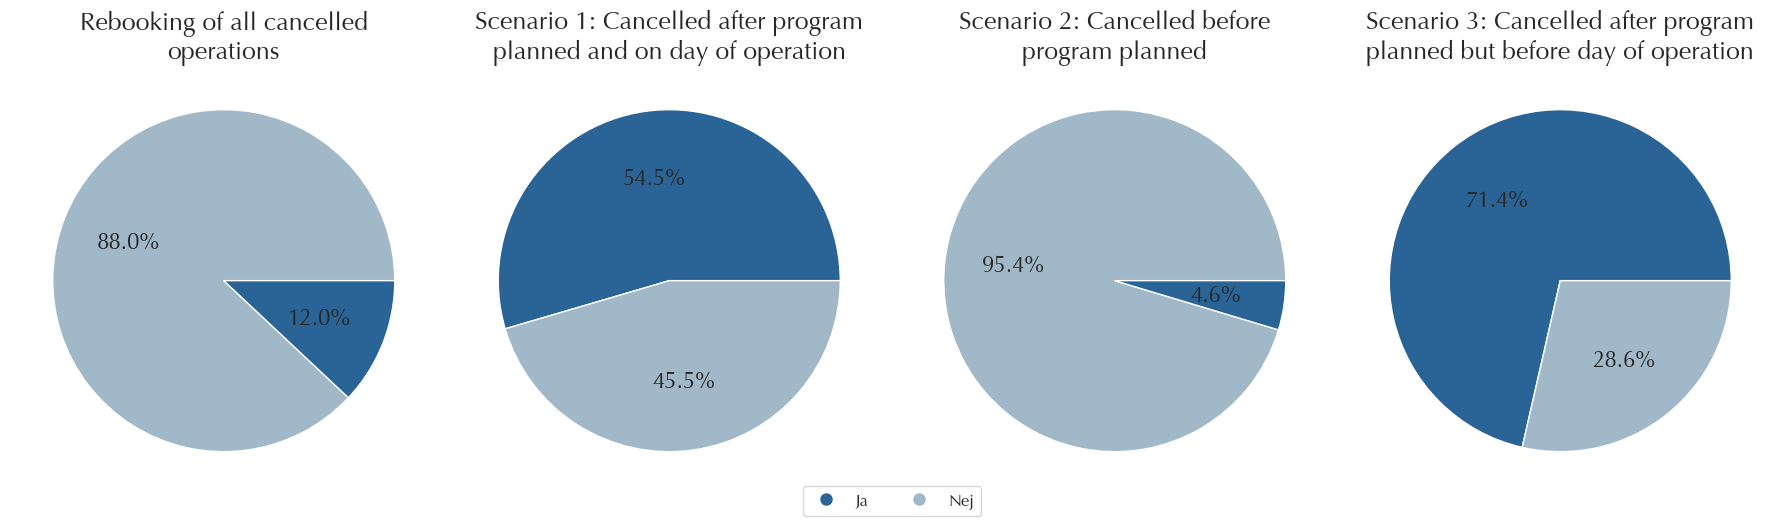

In [ ]:
aflyst_efter_planlægning =  df_actually_cancelled[df_actually_cancelled['Aflyst efter operationsprogrammet er afsluttet?'] == 'Ja']
aflyst_før_planlægning =  df_actually_cancelled[df_actually_cancelled['Aflyst efter operationsprogrammet er afsluttet?'] == 'Nej']
scenarie1 = aflyst_efter_planlægning[aflyst_efter_planlægning['Aflyst på dagen for operationen? '] == 'Ja']
scenarie2 = aflyst_før_planlægning[aflyst_før_planlægning['Aflyst på dagen for operationen? '] == 'Nej']
scenarie3 = aflyst_efter_planlægning[aflyst_efter_planlægning['Aflyst på dagen for operationen? '] == 'Nej']
ombookning_counts = df_actually_cancelled['Ombooket'].value_counts()
scenarie1_count = scenarie1['Ombooket'].value_counts()
scenarie2_count = scenarie2['Ombooket'].value_counts()
scenarie3_count = scenarie3['Ombooket'].value_counts()

print("scenarie1:", len(scenarie1) )
print("scenarie2:", len(scenarie2) )
print("scenarie3:", len(scenarie3) )

datasets = [
    ("Rebooking of all cancelled operations", ombookning_counts),
    ("Scenario 1: Cancelled after program planned and on day of operation", scenarie1_count),
    ("Scenario 2: Cancelled before program planned", scenarie2_count),
    ("Scenario 3: Cancelled after program planned but before day of operation", scenarie3_count),
]

# Colors
color_map = {
    "Ja": "#4CAF50",
    "Nej": "#F44336"
}

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
axes = axes.flatten()

for ax, (title, data) in zip(axes, datasets):
    labels = data.index
    colors = [color_map[label] for label in labels]

    ax.pie(
        data,
        labels=None,
        autopct='%1.1f%%',
        colors=colors,
        textprops={'fontsize': 16}  # slightly bigger % text
    )

    # Wrap titles and increase size
    wrapped_title = "\n".join(textwrap.wrap(title, 35))
    ax.set_title(wrapped_title, fontsize=18)

# Shared legend (bigger text)
handles = [
    plt.Line2D([0], [0], marker='o', color='w', label=key,
               markerfacecolor=color_map[key], markersize=10)
    for key in color_map
]

fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=12)

plt.tight_layout()
plt.show()